- **[0] 모듈 로딩**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib
from PIL import Image

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

- **[1] 데이터 준비** - iris 이미지 로드

In [ ]:
IMAGE_DIR = '../Data/Images/iris_images'
IMG_SIZE  = (64, 64)

x, y = [], []

for label in sorted(os.listdir(IMAGE_DIR)):
    label_path = os.path.join(IMAGE_DIR, label)
    for img_file in os.listdir(label_path):
        img_path = os.path.join(label_path, img_file)
        img = Image.open(img_path).resize(IMG_SIZE).convert('RGB')
        x.append(np.array(img).flatten())  # (64×64×3) = 12288 픽셀 벡터로 변환
        y.append(label)

x = np.array(x)
y = np.array(y)

print(f'x shape: {x.shape}')
print(f'클래스: {np.unique(y)}')
print(pd.Series(y).value_counts())

X shape: (421, 12288)
클래스: ['iris-setosa' 'iris-versicolour' 'iris-virginica']
iris-versicolour    269
iris-virginica       85
iris-setosa          67
Name: count, dtype: int64


- **[2] 데이터 전처리**

픽셀값 범위: 0.00 ~ 1.00


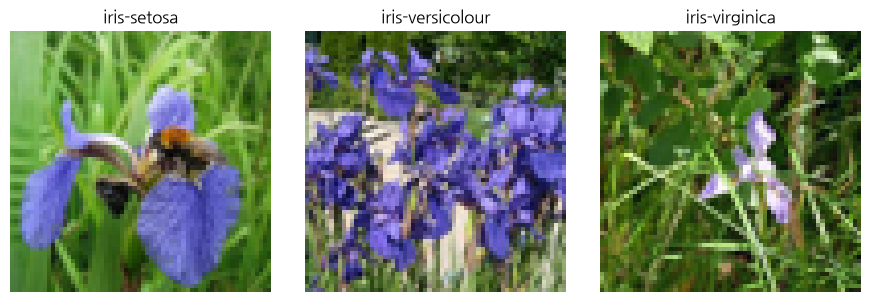

In [3]:
# 픽셀값 정규화 (0~255 → 0.0~1.0)
X = X / 255.0
print(f'픽셀값 범위: {X.min():.2f} ~ {X.max():.2f}')

# 샘플 이미지 확인
fig, axes = plt.subplots(1, 3, figsize=(9, 3))
classes = np.unique(y)
for ax, cls in zip(axes, classes):
    idx = np.where(y == cls)[0][0]
    ax.imshow(X[idx].reshape(64, 64, 3))
    ax.set_title(cls)
    ax.axis('off')
plt.tight_layout()
plt.show()

- **[3] 학습용 | 테스트용 데이터셋 준비**

In [4]:
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=10,
    stratify=y   # 클래스 비율 유지
)

print(f'학습 데이터: {x_train.shape}, 테스트 데이터: {x_test.shape}')

학습 데이터: (336, 12288), 테스트 데이터: (85, 12288)


- **[4] 하이퍼파라미터 튜닝 및 교차 검증**

In [5]:
k_model = KNeighborsClassifier()

param_dict = {
    'n_neighbors': range(1, 16, 2),
    'p': [1, 2],
    'weights': ['uniform', 'distance']
}
# => 전체 조합: 8 × 2 × 2 = 32가지

skFold = StratifiedKFold(n_splits=5, shuffle=True, random_state=10)

gs_model = GridSearchCV(
    k_model,
    param_grid=param_dict,
    cv=skFold,
    return_train_score=True,
    n_jobs=-1
)
gs_model.fit(x_train, y_train)

gs_best = gs_model.best_estimator_
print(f'Best params: {gs_model.best_params_}')
print(f'Best score : {gs_model.best_score_:.4f}')

Best params: {'n_neighbors': 15, 'p': 2, 'weights': 'uniform'}
Best score : 0.6340


- **[5] 학습 결과 분석 및 시각화**

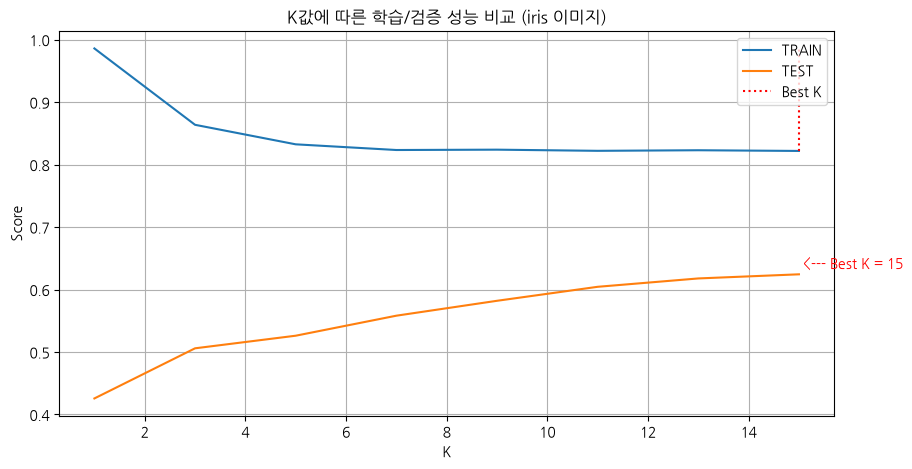

In [6]:
gs_cv = pd.DataFrame(gs_model.cv_results_)[['param_n_neighbors', 'mean_train_score', 'mean_test_score']]

totalDict = {'K': [], 'train_score': [], 'test_score': []}
for k in sorted(gs_cv['param_n_neighbors'].unique()):
    mask = gs_cv['param_n_neighbors'] == k
    totalDict['K'].append(k)
    totalDict['train_score'].append(gs_cv[mask]['mean_train_score'].mean())
    totalDict['test_score'].append(gs_cv[mask]['mean_test_score'].mean())
totalDF = pd.DataFrame(totalDict)
totalDF['Abs_Gap'] = abs(totalDF['train_score'] - totalDF['test_score'])

sortDF     = totalDF.sort_values(by=['test_score', 'Abs_Gap'], ascending=[False, True], ignore_index=True)
best_k     = sortDF.iloc[0]['K']
best_score = sortDF.iloc[0]['test_score']

plt.figure(figsize=(10, 5))
plt.plot(totalDF['K'], totalDF['train_score'], label='TRAIN')
plt.plot(totalDF['K'], totalDF['test_score'],  label='TEST')
plt.vlines(best_k, totalDF['train_score'].min(), totalDF['train_score'].max(),
           colors='red', linestyles='dotted', label='Best K')
plt.text(best_k, best_score + 0.01, f' <--- Best K = {int(best_k)}', c='red')
plt.title('K값에 따른 학습/검증 성능 비교 (iris 이미지)')
plt.xlabel('K')
plt.ylabel('Score')
plt.legend()
plt.grid()
plt.show()

- **[6] 예측 및 평가**
    * 테스트 데이터 기반 예측
    * 사용자 입력(이미지 경로) 기반 예측

In [7]:
# 테스트 데이터 기반 예측=
y_pred = gs_best.predict(x_test)

print(f'정확도(Accuracy): {accuracy_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred))

정확도(Accuracy): 0.6000

                  precision    recall  f1-score   support

     iris-setosa       0.38      0.21      0.27        14
iris-versicolour       0.63      0.89      0.74        54
  iris-virginica       0.00      0.00      0.00        17

        accuracy                           0.60        85
       macro avg       0.34      0.37      0.34        85
    weighted avg       0.46      0.60      0.51        85



In [8]:
# 이미지 경로 입력 기반 예측
img_path = input('이미지 파일 경로 입력: ').strip()

img = Image.open(img_path).resize(IMG_SIZE).convert('RGB')
img_array = np.array(img).flatten() / 255.0

y_pre = gs_best.predict([img_array])

plt.imshow(img)
plt.title(f'예측 결과: {y_pre[0]}')
plt.axis('off')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: ''